In [1]:
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
%load_ext autoreload
import src.processing as cl
import src.plotting as pl

In [13]:
#select which model to input, it will match with the model.in file
tag = 'COOLE'
tag2 = '1'
folder =  'example/COOLE/'
input_file = folder + 'v.in_' + tag + tag2
output_folder = folder
coords_file = 'line_coords'
start_lat, start_lon, end_lat, end_lon = cl.get_profile_coords(tag, tag2, coords_file)

In [12]:
# Apply parser to file
layers = cl.parse_velocity_model(input_file)

# Interpolate the velocity model to a regular grid
x_grid, z_grid, Vp_grid = cl.interpolate_velocity_model(layers, dx=1.0, dz=0.1, z_max=35.0)

#Convert x_grid to geographic coordinates
lon_grid, lat_grid = cl.interpolate_profile_coords(x_grid, start_lat, start_lon, end_lat, end_lon)

In [14]:
# --- SAVE LAYER BOUNDARIES TO CSV ---
boundary_rows = []
for layer in layers:
    for xi, zi in zip(layer["x"], layer["z"]):
        boundary_rows.append({"layer": layer["n"], "x": xi, "z": zi})

df_bounds = pd.DataFrame(boundary_rows)
df_bounds.to_csv(folder+tag+tag2+"_layers.csv", index=False)
print("Layer boundaries saved to " + tag + tag2 + "_layers.csv")

Layer boundaries saved to COOLE1_layers.csv


In [15]:
# --- SAVE INTERPOLATED GRID TO NETCDF ---
ds = xr.Dataset(
    data_vars={
        "vp": (("z", "x"), Vp_grid)
    },
    coords={
        "x": x_grid,
        "lon": ("x", lon_grid),
        "lat": ("x", lat_grid),
        "z": z_grid
    },
    attrs={
        "title": "Interpolated 2D Vp model",
        "description": "generated from " + tag,
        "units": "Vp in km/s, depth in km, distance in km"
    }
)
ds.to_netcdf(folder+tag+tag2+"_vp.nc")
print("Interpolated Vp grid saved to "+tag+tag2+"_vp.nc")

Interpolated Vp grid saved to COOLE1_vp.nc


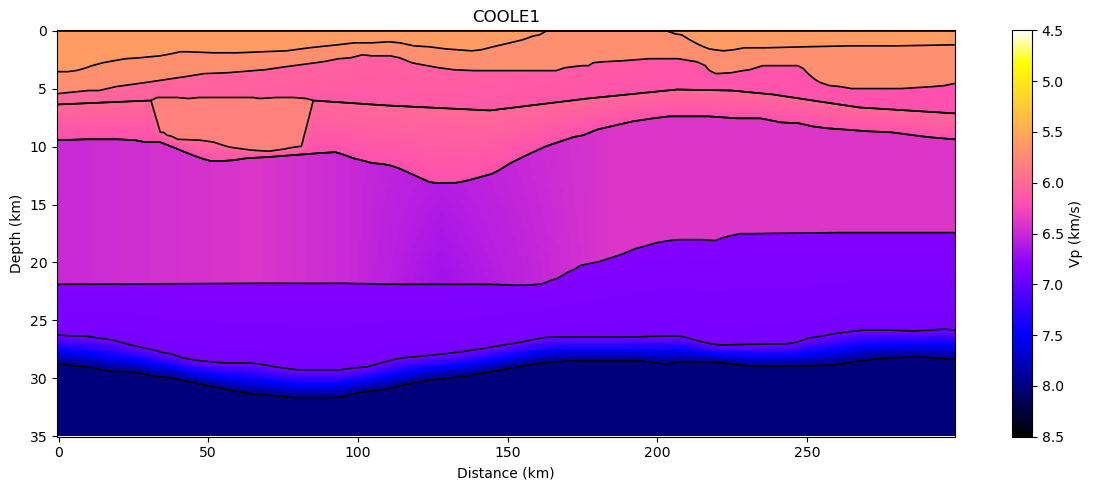

In [17]:
#check if the grid is correct
grid = output_folder + tag + tag2 + "_vp.nc"
layers = output_folder + tag + tag2 + "_layers.csv"
out = folder + tag + tag2 + "_vp.png"
pl.plot_section(grid, layers, title = tag+tag2, output=out)